In [62]:
import numpy as np 
import warnings
from scipy.optimize import root_scalar
import model_constants as const
import pandas as pd

In [2]:
####
# A Python version of the zero buoyancy plume model in Singh and O'Gorman (2013).

# >> Input parameters are:

# T_base : Base temperature of plume (K)
# qt_base: Base specific humidity of plume (kg/kg)
# p_base : Base pressure of plume (Pa)
# entrain: entrainment parameter (unitless)
#          Depends on "ent_type" (see optional arguments below)
#                 entrainment = entrain/z    [default]
#                 entrainment = entrain/1000
# RH     : environmental relative humidity (unitless, between 0 and 1)

# >> Optional arguments are:

# z_base  : Base height of plume (m) [50 m by default]
# z_top   : height to which pluem is integrated (m) [15000 m by default]
# gamma   : fraction of water that precipitates (0, 1) [1 by default]
#           0 = no fallout
#           1 = pseudo-adiabatic (all condensed water falls out immediately)
# ent_type: type of entrainment profile ['invz']
#         'invz': entrainment = entrain/z    [default]
#         'const': entrainment = entrain/1000
# deltaz  : vertical grid-spacing (m) [50 m by default]
# T_ice   : Temperature of total freezing condensate freezes 
#          gradually between 273.15 K and T_ice (K) [233.15 K by default]

# >> Outputs are:
# T_rho   : Density temperature (plume and env)   (K)
# T       : Temperature of plume                  (K)
# p       : pressure            (plume and env)   (K)
# qv      : specific humidity of plume            (kg/kg)
# qsat    : saturation specific humidity of plume (kg/kg)
# ql      : liquid water mass fraction of plume   (kg/kg)
# qi      : solid water mass fraction of plume    (kg/kg)
# z       : height                                (z)
# h       : plume moist static energy             (J/kg)
# T_env   : Temperature of environment            (K)
# q_env   : specific humidity of environment      (kg/kg)
# h_env   : environment moist static energy       (J/kg)
# ent     : entrainment rate                      (1/m)
#####

In [3]:
### function to check arguments are correct
def check_argument(var, varname, expected_type, varmin, varmax):
    """
    Check that an argument has the expected type and, if numeric,
    lies within the given bounds.

    Parameters
    ----------
    var : any
        Value to check.
    varname : str
        Name of the variable, used in error messages.
    expected_type : type or tuple[type, ...]
        Expected Python type, e.g. float, int, str, or (int, float).
    varmin : float
        Minimum allowed value for numeric inputs.
    varmax : float
        Maximum allowed value for numeric inputs.
    """
    if not isinstance(var, expected_type):
        if isinstance(expected_type, tuple):
            type_name = ", ".join(t.__name__ for t in expected_type)
        else:
            type_name = expected_type.__name__
        raise TypeError(f"Input: {varname} must be of type {type_name}")

    if isinstance(var, (int, float)):
        if var < varmin or var > varmax:
            raise ValueError(
                f"Input: {varname} outside of bounds [{varmin}, {varmax}]"
            )
    

In [4]:
def calc_fice(T, const=const):
    # Function to calculate the fraction of condensate that is ice.
    # All liquid for T > T0
    # All ice for T < T_ice
    # Linear function in between

    fliq = ( T-const.T_ice )/(const.T0-const.T_ice)
    if type(fliq)==float or type(fliq)==np.float64:
        if fliq<0:
            fliq=0
        elif fliq>1:
            fliq=1
    else:
        fliq[fliq<0] = 0
        fliq[fliq>1] = 1
    fice = 1-fliq

    return fliq, fice


def e_sat(T,const=const):
    # Function to calculate the saturation vapor pressure
    #
    # The functions are consistent with the constants given in the
    # model_constants subroutine. A faster option is available in which the
    # saturation curves are approximated as in Bolton (1980).
    #

    # Thermodynamically consistent definition of saturation curves
    # i.e. integral of Clausius-Clapeyron equation with constant heat
    # capacities. See Romps (2008).

    esl = const.e0*(T/const.T0)**((const.cpv-const.cpl)/const.Rv)* np.exp( ( const.Lv0 - const.T0*(const.cpv-const.cpl) )/const.Rv* ( 1/const.T0 - 1/T ) )

    esi = const.e0*(T/const.T0)**((const.cpv-const.cpi)/const.Rv)*np.exp( ( const.Ls0 - const.T0*(const.cpv-const.cpi) )/const.Rv* ( 1/const.T0 - 1/T ) )

    # If you want slightly faster (~10#) code, use these approximations 
    # (Bolton, 1980). Accurate to within 0.5# for T < 310 K.

    # esl = 611.2 *np. exp( 17.67      * ( T  - 273.15 ) / ( T  - 29.65 ) )
    # esi = 611.2 *np.exp( 21.8745584 * ( T  - 273.15 ) / ( T  - 7.66  ) )


    # Calculate ice fraction
    fliq,fice = calc_fice(T)

    es = fliq*esl + fice*esi

    return es, esl, esi

def qq_sat(T,p,qt=None, const=const):
    # Function to calculate the saturation specific humidity

    # Calculate saturation mixing ratio
    es, esl, esi = e_sat(T)
    rs = const.eps*es/(p-es)

    # Calculate saturation specific humidity using total water content if given
    if qt is not None:
        
        rt = qt/(1-qt)
        qs = rs/(1+np.nanmax([rt,rs]))
    else:
        qs = rs/(1+rs)
    
    return qs

def calc_saturation(p,T,q_t):
    # Function to calculate the specific humidities of vapor, liquid and solid
    # at saturation
    # calculate saturation specific humidity
    qs = qq_sat(T,p,q_t)
    q = np.minimum(q_t,qs)
    if type(q)==np.float64:
        if q<0:
            q=0
    else:
        q[q<0] = 0

    # Divide into liquid and ice
    fliq,fice = calc_fice(T)

    ql = fliq*(q_t-q)
    qi = fice*(q_t-q)

    if type(ql)==np.float64:
        if q_t-qs<0:
            ql=0
            qi=0
    else:
        ql[q_t-qs<0] = 0
        qi[q_t-qs<0] = 0


    return q,ql,qi

In [5]:
def calc_MSE(T,qt,p,z,const=const):
    # Function to calculate moist static energy

    # calculate proportions of vapor, liquid and solid
    qv,ql,qi = calc_saturation(p,T,qt)


    # calculate moist static energies of components
    hd = const.cp*(T-const.T0)  + const.g*z
    hv = const.cpv*(T-const.T0) + const.g*z + const.Lv0
    hl = const.cpl*(T-const.T0) + const.g*z
    hi = const.cpi*(T-const.T0) + const.g*z - (const.Ls0-const.Lv0)

    # Calculate moist static energy per unit mass of moist air
    h = hd*(1-qt) + qv*hv + ql*hl + qi*hi

    return h

In [6]:
def calc_Tv(T,RH,p,const=const):
    # Function to calculate virtual temperature at a given relative humidity

    # Calculate mixing ratio
    es, esl, esi  = e_sat(T)
    qv = const.eps*(RH*es/(p-RH*es*(1-const.eps)))

    # calculate virtual temperature
    Tv = T*(1+qv/const.eps-qv)

    return Tv

In [7]:
def fallout(gamma,ql,qi,dqls,T):
    # Function to calculate precipitation fallout terms

    e = np.minn([0,dqls/(1-ql-qi) ])

    fT = -gamma*e
    fliq,fice = calc_fice(T)

    fl = fT*fliq
    fs = fT*fice

    return fl, fs

In [63]:
def zero_buoyancy_plume(T_base = 300., qt_base = 0.0155, p_base= 100000., entrain = 0.5, RH = 0.7, 
                        z_base = 50., z_top = 15000., gamma = 1., ent_type = 'invz', deltaz = 50., T_ice = 233.15,
                        const=const, plotting=True, save_data=True):
    ## Add option to save data to csv for polishing and plotting later
    ## check input argument types first
    check_argument(T_base  ,'T_base'  ,(int,float),0     ,500   )
    check_argument(qt_base ,'qt_base' ,(int,float),0     ,1     )
    check_argument(p_base  ,'p_base'  ,(int,float),0     ,np.inf   )
    check_argument(entrain ,'entrain' ,(int,float),0     ,np.inf   )
    check_argument(RH      ,'RH'      ,(int,float),0     ,1     )
    check_argument(z_base  ,'z_base'  ,(int,float),0     ,z_top )
    check_argument(z_top   ,'z_top'   ,(int,float),z_base,np.inf   )
    check_argument(gamma   ,'gamma'   ,(int,float),0     ,1     )
    check_argument(ent_type,'ent_type',(str)      ,0     ,500   )
    check_argument(deltaz  ,'deltaz'  ,(int,float),0     ,np.inf   )
    check_argument(const.T_ice ,'T_ice'   ,(int,float),0     ,const.T0  )
    
    ## Set up height
    z = np.arange(z_base, z_top + deltaz, deltaz)
    if np.abs(z[-1] - z_top) > 0.1:
        z = np.append(z, z_top) # ensure last point is exactly z_top
    
    ## Set up entrainment profile
    if ent_type == 'invz':
        ent = np.minimum(1e-2, entrain / z)
    elif ent_type == 'const':
        ent = 0.001 * entrain * np.ones_like(z)
    else:
        raise ValueError("Invalid ent_type. Must be 'invz' or 'const'.")
    
    ## Initialize arrays to hold plume properties
    p       = np.zeros_like(z)
    logp    = np.zeros_like(z)

    qv      = np.zeros_like(z)
    qsat    = np.zeros_like(z)
    ql      = np.zeros_like(z)
    qi      = np.zeros_like(z)
    qt      = np.zeros_like(z)

    T       = np.zeros_like(z)
    T_rho   = np.zeros_like(z)

    h       = np.zeros_like(z)

    T_env   = np.zeros_like(z)
    q_env   = np.zeros_like(z)
    h_env   = np.zeros_like(z)
    
    ## Initial conditions
    p[0] = p_base
    T[0] = T_base
    qt[0] = qt_base
    
    ## Determine if there is any liquid or solid water
    qv[0],ql[0],qi[0] = calc_saturation(p_base,T_base,qt_base)
    
    if ql[0] > 0 or qi[0] > 0:
        warnings.warn("plume base super-saturated", category=UserWarning)
    
    ## Derived properties 
    logp[0] = np.log(p[0])
    h[0] = calc_MSE(T[0],qt[0],p[0],z[0])
    
    ## Flag for LCL level
    LCL = 0
    
    ## Integrate model upward
    for i in range(0,len(z)):
        # Calculate plume density temperature
        T_rho[i] = T[i]*(1+qv[i]/const.eps - qt[i])
        
        # Calculate plume saturation specific humidity
        qsat[i] = qq_sat(T[i],p[i],qt[i])
        
        
        # Calculate environment properties
        # Assume:
        #           1) equal density to plume
        #           2) Fixed relative humidity
        
        # Tv(env) = T_rho(plume)
        # Use root finding algorithm with initial guess
        T_env[i] = root_scalar(lambda x: calc_Tv(x, RH, p[i]) - T_rho[i],
                               x0=T[i] * (1 + 0.61 * RH * qv[i]),
                               method="newton"
                               )["root"]
        
        # Calculate environment humidity based on assumed relative humidity
        es_tmp, _, _ = e_sat(T_env[i])
        e_env = RH*es_tmp
        q_env[i] = const.eps*(e_env/(p[i]-e_env*(1-const.eps)))
        
        # Calculate environment moist static energy
        h_env[i] = calc_MSE(T_env[i],q_env[i],p[i],z[i])
        
        if i<len(z)-1:
               
            # No entrainment if unsaturated
            # Include LCL flag to prevent entrainment turning off above LCL
            if (qt[i]-qsat[i]) < 0 and LCL == 0:
                ent[i]=0
            else:
                LCL = 1
                        
            # Step upward - simple Euler method
            h[i+1] =    h[i] - ent[i]*( h[i] - h_env[i] ) *( z[i+1]-z[i] )
            qt[i+1] =   qt[i] - ent[i]*( qt[i]-q_env[i] )  *( z[i+1]-z[i] )
            logp[i+1] = logp[i] - const.g/(const.Rd*T_rho[i])   *( z[i+1]-z[i] )
            
            # Calculate pressure
            p[i+1]  = np.exp(logp[i+1])
            
            # Calculate Temperature via root finding algorithm
            T[i+1]  = root_scalar(lambda x: calc_MSE(x, qt[i+1], p[i+1], z[i+1]) - h[i+1],
                                  x0=T[i], method="newton"
                               )["root"]
            
            # Calculate humidity
            qv[i+1],ql[i+1],qi[i+1] = calc_saturation(p[i+1],T[i+1],qt[i+1])
            
            
            # Rainfall fallout ################################################
            
            if qt[i+1]-qv[i+1]>0 and gamma > 0:
                
                if gamma>=1: # Total fallout:
                    
                    #   1) Set q to its saturation value
                    qt[i+1] = qq_sat(T[i+1],p[i+1])
                    qv[i+1],ql[i+1],qi[i+1] = calc_saturation(p[i+1],T[i+1],qt[i+1])
                    
                    #   2) Recalculate moist static energy
                    h[i+1]  = calc_MSE(T[i+1],qt[i+1],p[i+1],z[i+1])
                    
                else:        # Partial fallout:
                    
                    # Calculate increase in liquid/solid water
                    # Assume fallout is proportional to this value
                    dqls = -(ql[i+1]+qi[i+1]-ql[i]-qi[i])
                    
                    # Calculate fallout
                    fl,fs = fallout(gamma,ql[i+1],qi[i+1],dqls,T[i+1])
                    
                    # Minimum value of total water is saturation value
                    qtmin = qq_sat(T[i+1],p[i+1])
                    
                    # Adjust total water, prevent reduction below saturation
                    qt[i+1] = np.max([qt[i+1] - (fl+fs)*(1-qt[i+1]),qtmin])
                    
                    # Adjust moist static energy
                    h[i+1]  = calc_MSE(T[i+1],qt[i+1],p[i+1],z[i+1])
                    
                    # Recalculate water species breakdown
                    [qv[i+1],ql[i+1],qi[i+1]] = calc_saturation(p[i+1],T[i+1],qt[i+1])
    
    if plotting:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 8))
        plt.subplot(121)
        plt.plot(T_rho,z/1000, "r")
        plt.xlabel("$T_rho$ (K)")
        plt.ylabel("z (km)")
        plt.title("(a) Density Temperature Profile")
        
        plt.subplot(122)
        plt.plot(h/1000,z/1000, "r", label="plume")
        plt.plot(h_env/1000,z/1000, "b", label="environment")
        plt.xlabel("MSE (kJ/kg)")
        plt.ylabel("z (km)")
        plt.title("(b) Density Temperature Profile")
        plt.legend()
        plt.savefig("zbp_profiles.png", dpi=300)
    
            
    df = pd.DataFrame({
        'z': z,
        'T_rho': T_rho,
        'T': T,
        'p': p,
        'qv': qv,
        'qsat': qsat,
        'ql': ql,
        'qi': qi,
        'h': h,
        'T_env': T_env,
        'q_env': q_env,
        'h_env': h_env,
        'ent': ent
    })
    if save_data:
        df.to_csv('zero_buoyancy_plume_output.csv', index=False)
            
    return df
    
    

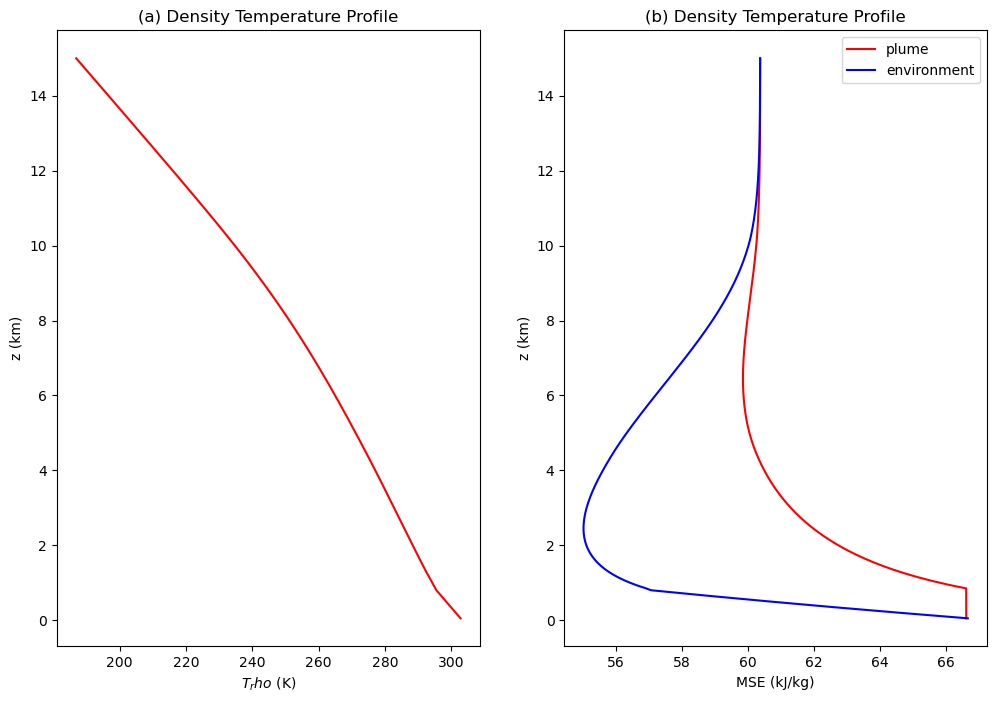

In [64]:
if __name__ == "__main__":
    output = zero_buoyancy_plume(plotting=True, save_data=True)
   